### Tareas

- Diagrama entidad relacion (Daro)
- Analisis exploratorio de los datos (Pablo y Ana)
- Propuesta de indicadores + prototipo de dashboard (Noe y Esteban)

# 0. Librerias

In [43]:
# Manejo de archivos y operaciones matemáticas
import math
import os

# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Visualización de datos
import sweetviz as sv
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Constantes
from  constants import DATA_RAW


# 1. Ingesta de datos 

In [44]:
df = pd.read_csv(DATA_RAW)

# 2. Limpieza de Datos

## 2.1 Revisión de Estructura General

In [45]:
df.head(5)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,2023,Germany,Munich,32,Mid
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,2016,Spain,Seville,43,Senior
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior


In [46]:
df.tail(5)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
1999995,EMP1999996,Ottmar Kusch-Dörschner,IT,Software Developer,2020-11-30,Good,15,Active,Hybrid,136684.0,2020,Germany,Frankfurt,44,Senior
1999996,EMP1999997,Isis Wagenvoort,Sales,Sales Manager,2024-06-06,Good,3,Active,On-site,57911.0,2024,Netherlands,Amsterdam,25,Junior
1999997,EMP1999998,Ángel Gomez Arenas,Sales,Sales Manager,2020-05-21,Excellent,14,Active,Remote,146065.0,2020,Spain,Valencia,39,Senior
1999998,EMP1999999,Carmela Weiß,Sales,Business Development,2018-07-11,Excellent,9,Active,Remote,138855.0,2018,Germany,Frankfurt,35,Senior
1999999,EMP2000000,Macario Casals,IT,Software Developer,2025-09-11,Good,1,Active,Hybrid,46067.0,2025,Spain,Madrid,28,Junior


In [47]:
df.columns

Index(['Employee_ID', 'Full_Name', 'Department', 'Job_Title', 'Hire_Date',
       'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode',
       'Salary', 'Year', 'Country', 'City', 'Age', 'Job_Level'],
      dtype='object')

In [48]:
df.shape

(2000000, 15)

In [49]:
df.dtypes

Employee_ID            object
Full_Name              object
Department             object
Job_Title              object
Hire_Date              object
Performance_Rating     object
Experience_Years        int64
Status                 object
Work_Mode              object
Salary                float64
Year                    int64
Country                object
City                   object
Age                     int64
Job_Level              object
dtype: object

In [50]:
# Transformaciones a realizar  y mejoras 

# 1. Fechas
df["Hire_Date"] = pd.to_datetime(df["Hire_Date"], errors="coerce")

# 2. Salary
df["Salary"] = df["Salary"].astype("int32")

"""
# 3. Drop redundante -- Primero verificar si coincide con year
df = df.drop(columns=["Year"])
"""

# 4. Categoricals
cols_cat = ["Department", "Job_Title", "Status", "Work_Mode",
            "Country", "City", "Job_Level", "Performance_Rating"]

for col in cols_cat:
    df[col] = df[col].astype("category")

# 5. Optimización numérica
df["Experience_Years"] = df["Experience_Years"].astype("int16")
df["Age"] = df["Age"].astype("int16")

## 2.2 Revision de Nulos 

In [51]:
df.isnull().sum().sort_values(ascending=False)


Performance_Rating    3333
Full_Name                0
Employee_ID              0
Department               0
Job_Title                0
Hire_Date                0
Experience_Years         0
Status                   0
Work_Mode                0
Salary                   0
Year                     0
Country                  0
City                     0
Age                      0
Job_Level                0
dtype: int64

Reviso si existe algun otro tipo de nulo que este formateado como un string nan,0,-

In [52]:
columns=['Department', 'Job_Title', 
       'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode',
       'Salary', 'Year', 'Country', 'City', 'Age', 'Job_Level']

for col in columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))
    print("-------------------------------------------")


 Department
Department
Sales         600633
IT            499325
Operations    400595
Finance       299955
HR            199492
Name: count, dtype: int64
-------------------------------------------

 Job_Title
Job_Title
Sales Manager           120595
Sales Executive         120349
Sales Director          119971
Regional Lead           119886
Business Development    119832
IT Manager              100132
System Admin            100103
DevOps Engineer          99886
Data Engineer            99747
Software Developer       99457
Operations Director      80346
Logistics                80242
Operations Manager       80119
Supply Chain             80025
Operations Analyst       79863
Accountant               60125
Tax Specialist           60050
Financial Analyst        60017
CFO                      59921
Finance Manager          59842
HR Coordinator           40070
HR Manager               39989
HR Director              39887
Talent Specialist        39848
Recruiter                39698
Name

In [53]:
# Transformaciones a realizar  y mejoras 

# Aca lo pense a futuro como cambiaria en caso de tener otros tipos de numeros nulos
missing_ratio = df['Performance_Rating'].isnull().mean()

if missing_ratio < 0.01:
    df = df.dropna(subset=['Performance_Rating'])

elif missing_ratio < 0.05:
    # imputación por grupo con fallback global
    global_mode = df['Performance_Rating'].mode().iloc[0]

    def fill_group(x):
        if x.mode().empty:
            return x.fillna(global_mode)
        return x.fillna(x.mode().iloc[0])

    df['Performance_Rating'] = (
        df.groupby(['Job_Level', 'Department'])['Performance_Rating']
          .transform(fill_group)
    )

else:
    # imputación probabilística (mejor con seed)
    np.random.seed(42)

    dist = df['Performance_Rating'].value_counts(normalize=True)

    df.loc[df['Performance_Rating'].isnull(), 'Performance_Rating'] = \
        np.random.choice(
            dist.index,
            size=df['Performance_Rating'].isnull().sum(),
            p=dist.values
        )

## 2.3 Revision de Duplicados

In [54]:
# Reviso si hay filas duplicadas 
df[df.duplicated(keep=False)]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level


In [55]:
# Reviso si hay Ids duplicados
df[df.duplicated(subset=["Employee_ID"], keep=False)].sort_values(by="Employee_ID")


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level


In [56]:
# ver empleados duplicados
df[df.duplicated(subset=["Full_Name"], keep=False)].sort_values("Full_Name")

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
1233693,EMP1233694,Aaliyah Ansems,IT,Data Engineer,2022-11-26,Good,2,Active,Remote,53005,2022,Netherlands,Amsterdam,25,Junior
1613661,EMP1613662,Aaliyah Ansems,IT,Software Developer,2020-01-08,Good,1,Active,On-site,59408,2020,Netherlands,The Hague,30,Junior
1858581,EMP1858582,Aaliyah Arens,Operations,Operations Analyst,2025-09-30,Excellent,0,Active,Hybrid,50928,2025,Netherlands,Eindhoven,21,Junior
1651398,EMP1651399,Aaliyah Arens,Sales,Sales Executive,2023-05-31,Excellent,6,Active,On-site,96787,2023,Netherlands,Amsterdam,28,Mid
979926,EMP0979927,Aaliyah Bresse,Operations,Logistics,2023-10-21,Good,4,Active,On-site,90978,2023,Netherlands,Utrecht,31,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086330,EMP1086331,Łukasz Sugier,IT,DevOps Engineer,2025-08-14,Excellent,3,Active,Hybrid,56234,2025,Poland,Warsaw,23,Junior
1272116,EMP1272117,Łukasz Swiątek,IT,IT Manager,2018-08-09,Excellent,11,Active,On-site,138440,2018,Poland,Warsaw,31,Senior
1974494,EMP1974495,Łukasz Swiątek,Operations,Operations Manager,2025-06-06,Satisfactory,2,Active,Remote,40386,2025,Poland,Warsaw,25,Junior
1035955,EMP1035956,Łukasz Wójcikiewicz,Finance,CFO,2023-08-05,Good,6,Active,On-site,77279,2023,Poland,Poznan,32,Mid


REVISAR CON EL EQUIPO 

Si bien no hay datos duplicados tengo la duda en el caso de los homonimos sera que son personas que cambian de puesto, o simplemente personas con el mismo nombre?


## 2.4 Valores Fuera de rango 

In [57]:
errors = {}

# Salarios Negativos (< 0)
errors["Salarios_Negativos"] = df[df["Salary"] < 0]

# Años de experiencia negativa  (< 0)
errors["Años_Exp_Negativa"] = df[df["Experience_Years"] < 0]

for k, v in errors.items():
    print(f"{k}: {len(v)} ({len(v)/len(df)*100:.2f}%)")

Salarios_Negativos: 3333 (0.17%)
Años_Exp_Negativa: 2421 (0.12%)


Tema saliarios

Primero pense en revisar si estaban muy fuera de rango del gruop departament, job level. Y en funcion de eso decidir si imputar con la mediana o aplicar un valor absoluto porque suponia que fue un error de tipeo del empleado (consultar al equipo)

In [60]:
# ================================
# 1. Detectar negativos
# ================================
neg = df[df['Salary'] < 0].copy()
neg['orig_index'] = neg.index

# ================================
# 2. Merge con rangos
# ================================
neg = neg.merge(
    group_bounds[['lower','upper']],
    on=['Job_Level','Department'],
    how='left'
)

# ================================
# 3. Evaluar
# ================================
neg['abs_salary'] = neg['Salary'].abs()
neg['in_range'] = (neg['abs_salary'] >= neg['lower']) & (neg['abs_salary'] <= neg['upper'])

# ================================
# 4. Métricas
# ================================
total_neg = len(neg)
in_range = neg['in_range'].sum()
out_range = total_neg - in_range

print(f"Total negativos: {total_neg}")
print(f"Dentro de rango (usar abs): {in_range} ({in_range/total_neg:.2%})")
print(f"Fuera de rango (imputar): {out_range} ({out_range/total_neg:.2%})")

# ================================
# 5. Aplicar correcciones (usando índice original)
# ================================

# 5.1 corregir con abs
df.loc[neg.loc[neg['in_range'], 'orig_index'], 'Salary'] = \
    neg.loc[neg['in_range'], 'abs_salary'].values

# 5.2 fuera de rango → NaN
df.loc[neg.loc[~neg['in_range'], 'orig_index'], 'Salary'] = np.nan

# ================================
# 6. Imputación
# ================================
df['Salary'] = df['Salary'].fillna(
    df.groupby(['Job_Level', 'Department'])['Salary'].transform('median')
)

"""
# fallback global
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
"""

Total negativos: 3333
Dentro de rango (usar abs): 1021 (30.63%)
Fuera de rango (imputar): 2312 (69.37%)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15244\2042025611.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Job_Level', 'Department'])['Salary'].transform('median')


"\n# fallback global\ndf['Salary'] = df['Salary'].fillna(df['Salary'].median())\n"

In [61]:
# Realizo limpieza de años de experiencia negativa 
df.loc[df['Experience_Years'] < 0, 'Experience_Years'] = df.loc[df['Experience_Years'] < 0, 'Experience_Years'].abs()

In [62]:
errors = {}

# Salarios Negativos (< 0)
errors["Salarios_Negativos"] = df[df["Salary"] < 0]

# Años de experiencia negativa  (< 0)
errors["Años_Exp_Negativa"] = df[df["Experience_Years"] < 0]

for k, v in errors.items():
    print(f"{k}: {len(v)} ({len(v)/len(df)*100:.2f}%)")

Salarios_Negativos: 0 (0.00%)
Años_Exp_Negativa: 0 (0.00%)


## 2.5 Incoherencias y Reglas de negocio

In [70]:
errors = {}

# Inactivos con salarios 
errors["Inactivos_con_Salario"] = df[(df["Status"] != "Active") & (df["Salary"] > 0)]

# Activos con salario 0 
errors["Activos_con_Salario_nulo"] = df[(df["Status"] == "Active") & (df["Salary"] == 0)]


# Edad invalida (< 0)
errors["Edad_Invalida"] = df[(df["Age"] < 18) | (df["Age"] > 70)]

# Experiencia es mayor que los posibles años laborales 
errors["Exp_mayor_edad"] = df[df["Experience_Years"] > df["Age"] - 18]

errors["Dif_hire_date_years"] = df[df["Hire_Date"].dt.year > df["Year"]]

for k, v in errors.items():
    print(f"{k}: {len(v)} ({len(v)/len(df)*100:.2f}%)")

Inactivos_con_Salario: 206072 (10.32%)
Activos_con_Salario_nulo: 0 (0.00%)
Edad_Invalida: 0 (0.00%)
Exp_mayor_edad: 21 (0.00%)
Dif_hire_date_years: 0 (0.00%)


In [71]:
errors["Exp_mayor_edad"]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level
22594,EMP0022595,Gilles-Gilbert Mahe,Sales,Regional Lead,2025-09-21,Good,5,Active,Hybrid,57353.0,2025,France,Nice,22,Junior
137536,EMP0137537,Apolinar Quesada-Cañete,IT,System Admin,2025-12-21,Satisfactory,5,Active,Remote,48897.0,2025,Spain,Barcelona,22,Junior
146721,EMP0146722,Mr George Heath,Sales,Sales Executive,2024-08-18,Satisfactory,4,Active,Remote,49018.0,2024,United Kingdom,London,21,Junior
207461,EMP0207462,Josette de la Brunel,IT,System Admin,2025-05-09,Excellent,4,Active,Hybrid,50916.0,2025,France,Marseille,21,Junior
223477,EMP0223478,Filippa Vecellio,Sales,Business Development,2018-12-29,Good,5,Active,On-site,48939.0,2018,Italy,Milan,22,Junior
327944,EMP0327945,Miss Louise Johnson,IT,IT Manager,2016-11-15,Satisfactory,5,Active,Hybrid,60902.0,2016,United Kingdom,Manchester,22,Junior
479965,EMP0479966,Olivie Renard,Operations,Logistics,2025-01-29,Good,5,Active,Remote,41256.0,2025,France,Toulouse,21,Junior
671664,EMP0671665,Nathan Harrison,Sales,Sales Executive,2018-09-11,Satisfactory,5,Active,On-site,46791.0,2018,United Kingdom,Birmingham,22,Junior
729053,EMP0729054,Dr Kenneth Taylor,HR,HR Manager,2023-08-30,Excellent,5,Active,Remote,47157.0,2023,United Kingdom,Manchester,21,Junior
790936,EMP0790937,Henner Stadelmann,Sales,Sales Director,2024-10-13,Needs Improvement,5,Active,On-site,42534.0,2024,Germany,Frankfurt,22,Junior


In [ ]:
# La columna year es derivable de Hire_Date por lo tanto por reduncia se recomienda eliminarla del modelado
df = df.drop(columns=['Year'])


In [ ]:
#Revision de salarios 

# Aca agrupe los salarios por nivel de trabajo y departamento y me puse a ver que tan lejos estaban de la media (Preguntar a Noemi sobre esto estadistico)
# Puso un z score de desvio y respecto a eso fue que voy a ver cuales son los outliers. En funcion de eso mi duda es que hacemos con esto jajaja como regla de negocio que comprendemos 
group_cols = ["Job_Level", "Department"]

df["salary_mean"] = df.groupby(group_cols)["Salary"].transform("mean")
df["salary_std"] = df.groupby(group_cols)["Salary"].transform("std")

# Z-score (distancia en desviaciones estándar)
df["salary_zscore"] = (df["Salary"] - df["salary_mean"]) / df["salary_std"]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15244\192392422.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["salary_mean"] = df.groupby(group_cols)["Salary"].transform("mean")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15244\192392422.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["salary_std"] = df.groupby(group_cols)["Salary"].transform("std")


,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Country,City,Age,Job_Level,salary_mean,salary_std,salary_zscore
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8,Active,On-site,92992.0,Germany,Munich,32,Mid,87518.435085,8303.956975,0.659151
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11,Active,On-site,112318.0,Netherlands,Eindhoven,43,Senior,117692.684403,12839.870780,-0.418593
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15,Active,On-site,111121.0,Spain,Seville,43,Senior,117692.684403,12839.870780,-0.511819
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1,Active,Hybrid,49012.0,France,Marseille,23,Junior,47113.039499,5176.638341,0.366833
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2,Active,On-site,57553.0,United Kingdom,Edinburgh,31,Junior,50660.490137,6057.125001,1.137918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,EMP1999996,Ottmar Kusch-Dörschner,IT,Software Developer,2020-11-30,Good,15,Active,Hybrid,136684.0,Germany,Frankfurt,44,Senior,149161.395956,14971.945008,-0.833385
1999996,EMP1999997,Isis Wagenvoort,Sales,Sales Manager,2024-06-06,Good,3,Active,On-site,57911.0,Netherlands,Amsterdam,25,Junior,50660.490137,6057.125001,1.197022
1999997,EMP1999998,Ángel Gomez Arenas,Sales,Sales Manager,2020-05-21,Excellent,14,Active,Remote,146065.0,Spain,Valencia,39,Senior,143510.756112,14860.974825,0.171876
1999998,EMP1999999,Carmela Weiß,Sales,Business Development,2018-07-11,Excellent,9,Active,Remote,138855.0,Germany,Frankfurt,35,Senior,143510.756112,14860.974825,-0.313287


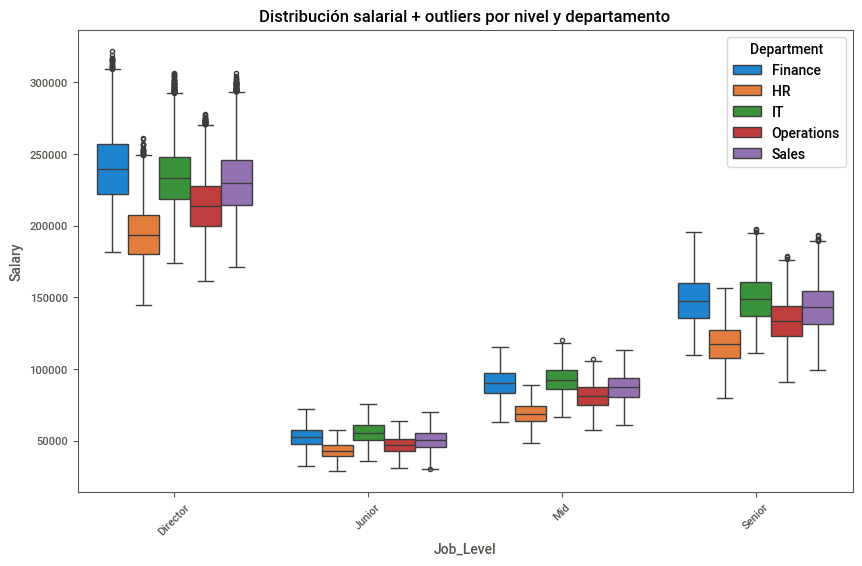

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15244\1675306745.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outliers.groupby(["Job_Level", "Department"]).size().sort_values(ascending=False)


Job_Level  Department
Mid        Sales         4224
           IT            3710
           Operations    2831
Senior     Sales         2778
           IT            2463
Mid        Finance       2037
Senior     Operations    1811
Junior     IT            1684
           Sales         1528
Mid        HR            1363
Senior     Finance       1349
Junior     Operations    1349
Director   Sales         1106
           IT             961
Junior     Finance        869
Senior     HR             810
Director   Operations     764
Junior     HR             684
Director   Finance        529
           HR             394
dtype: int64

In [75]:
# Dudas : Tengo dudas porque no se si estoy tomando la inflacion de la moneda puede que el salario cambie año a año para el mismo puesto 
# Consultar con el equipo
outliers = df[df["salary_zscore"].abs() > 2]
outliers

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Job_Level",
    y="Salary",
    hue="Department"
)

plt.xticks(rotation=45)
plt.title("Distribución salarial + outliers por nivel y departamento")
plt.show()
# Ana despues chusmea esto por ahi se pueda 
outliers.groupby(["Job_Level", "Department"]).size().sort_values(ascending=False)


## 5. Outliers

## 6. Inconsistencia logica

## Revision de los salarios 

7. Rangos
8. Relaciones
9. Claves
10. Distribución
11. Irrelevantes
12. Calidad / sesgos

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col}")
    plt.show()

# 5. Análisis exploratorio (EDA) - Analítica


In [ ]:
report = sv.analyze(df)
report.show_html()

In [ ]:
df_grouped = df.groupby(['Department', 'Job_Title']).size().reset_index(name='Total_Employees')
df_grouped 


Posible Organigrama
![Organigrama](Bosquejo_Organigrama.png)

# 6. Visualización de datos (Data Visualization)

# 7. Generación de insights (Conclusiones)

---

# Esquema de BD

## Versión operacional 
El modelo operacional está diseñado para representar el estado actual de los empleados, sin preservar historial de cambios. Refleja la fotografía presente del dataset. 

![HR-OPERACIONAL](esquemas/HR_OPERACIONAL_2026-04-18T15_00_35.392Z.png)

## Versión BI
Está optimizado para consultas analíticas, agregaciones y análisis histórico. En este modelo, los datos se cargan en snapshots semanales acumulativos, lo que permite responder preguntas sobre la evolución del headcount, salarios y performance a lo largo del tiempo.

![HR-BI](esquemas/HR_ESTRELLA_BI_2026-04-18T15_00_39.671.png)

La explicacón en detalle de los campos y diferencias esta en [Documento](esquemas/Documentacion_Modelos_HR.pdf)